In [4]:
import pandas as pd
import nltk
import string
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk

In [6]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [2]:
df = pd.read_csv("movie_reviews_dataset.csv")

In [3]:
df

,review,label
0,One of the best movies I have ever watched,1
1,Highly recommended movie for everyone,1
2,This movie was amazing and the acting was fant...,1
3,Completely waste of time,0
4,Absolutely loved the cinematography and direction,1
...,...,...
9995,Highly recommended movie for everyone,1
9996,I really loved this film it was wonderful,1
9997,One of the best movies I have ever watched,1
9998,Terrible acting and bad screenplay,0


In [8]:
def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

def remove_special(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

stop_words = set(stopwords.words("english"))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [9]:
df["review"] = df["review"].str.lower()
df["review"] = df["review"].apply(remove_punctuation)
df["review"] = df["review"].apply(remove_special)
df["tokens"] = df["review"].apply(word_tokenize)
df["tokens"] = df["tokens"].apply(remove_stopwords)
df["tokens"] = df["tokens"].apply(lemmatization)

df["clean_review"] = df["tokens"].apply(lambda x: " ".join(x))

In [12]:
df[["review", "clean_review", "label"]]

,review,clean_review,label
0,one of the best movies i have ever watched,one best movie ever watched,1
1,highly recommended movie for everyone,highly recommended movie everyone,1
2,this movie was amazing and the acting was fant...,movie amazing acting fantastic,1
3,completely waste of time,completely waste time,0
4,absolutely loved the cinematography and direction,absolutely loved cinematography direction,1
...,...,...,...
9995,highly recommended movie for everyone,highly recommended movie everyone,1
9996,i really loved this film it was wonderful,really loved film wonderful,1
9997,one of the best movies i have ever watched,one best movie ever watched,1
9998,terrible acting and bad screenplay,terrible acting bad screenplay,0


In [16]:
example = word_tokenize("The movie was absolutely fantastic")

pos_tags = pos_tag(example)

pos_tags

[('The', 'DT'),
 ('movie', 'NN'),
 ('was', 'VBD'),
 ('absolutely', 'RB'),
 ('fantastic', 'JJ')]

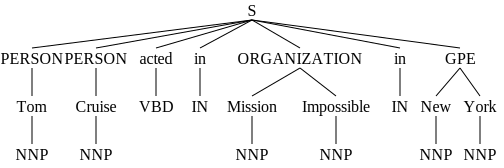

In [15]:
sentence = word_tokenize("Tom Cruise acted in Mission Impossible in New York")

pos_tags = pos_tag(sentence)

ner = ne_chunk(pos_tags)

ner